<a href="https://colab.research.google.com/github/AnnisaFarikha/Visi-Komputer/blob/main/Jobsheet03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Praktikum D1 - Regresi dari Citra Sintetis (Prediksi Radius Lingkaran)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow.keras import layers, models

# Generator 1 sample
def make_sample(img_size=64, min_r=5, max_r=20):
  r = np.random.randint(min_r, max_r + 1) #radius acak
  img = np.zeros((img_size, img_size), dtype=np.uint8)
  cx = np.random.randint(r, img_size - r) #center-x
  cy = np.random.randint(r, img_size - r) #center-y
  cv2.circle(img, (cx, cy), r, (255,), -1) #lingkaran putih terisi
  img = (img / 255.0).astype(np.float32)
  # 3-channel biar kompatibel CNN
  img3 = np.stack([img, img, img], axis=-1)
  return img3, float(r), (cx, cy)

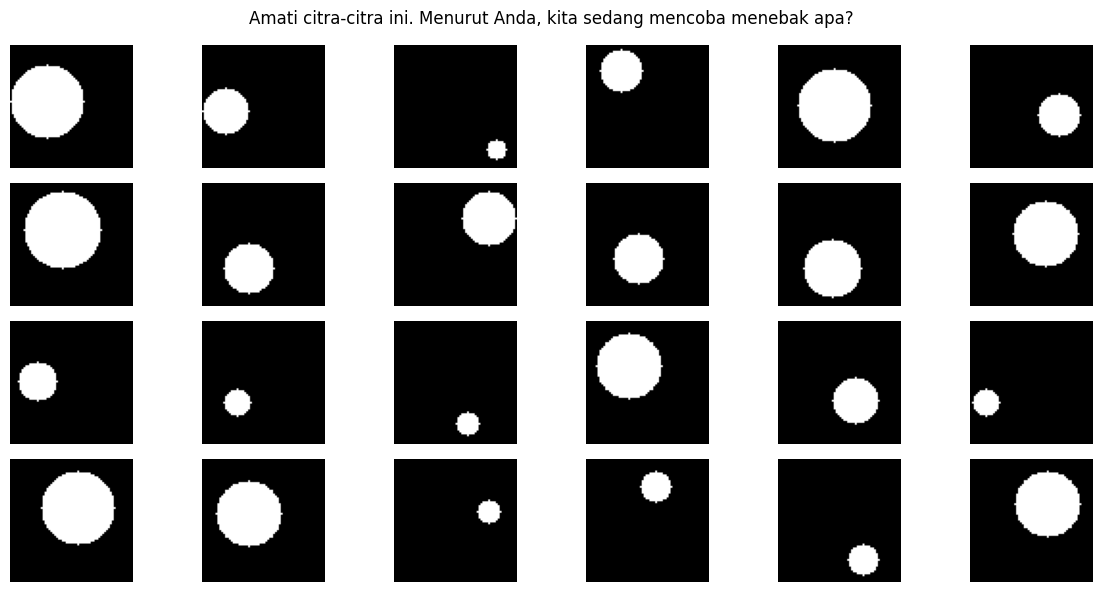

In [ ]:
# Buat 24 contoh untuk visualisasi
N_show = 24
samples = [make_sample() for _ in range(N_show)]
imgs = [s[0] for s in samples]
rads = [s[1] for s in samples]
centers = [s[2] for s in samples]

# Grid gambar tanpa label:
cols = 6
rows = N_show // cols
plt.figure(figsize=(12, 6))
for i in range(N_show):
  plt.subplot(rows, cols, i+1)
  plt.imshow(imgs[i].squeeze(), cmap='gray')
  plt.axis('off')
plt.suptitle("Amati citra-citra ini. Menurut Anda, kita sedang mencoba menebak apa?")
plt.tight_layout()
plt.show()

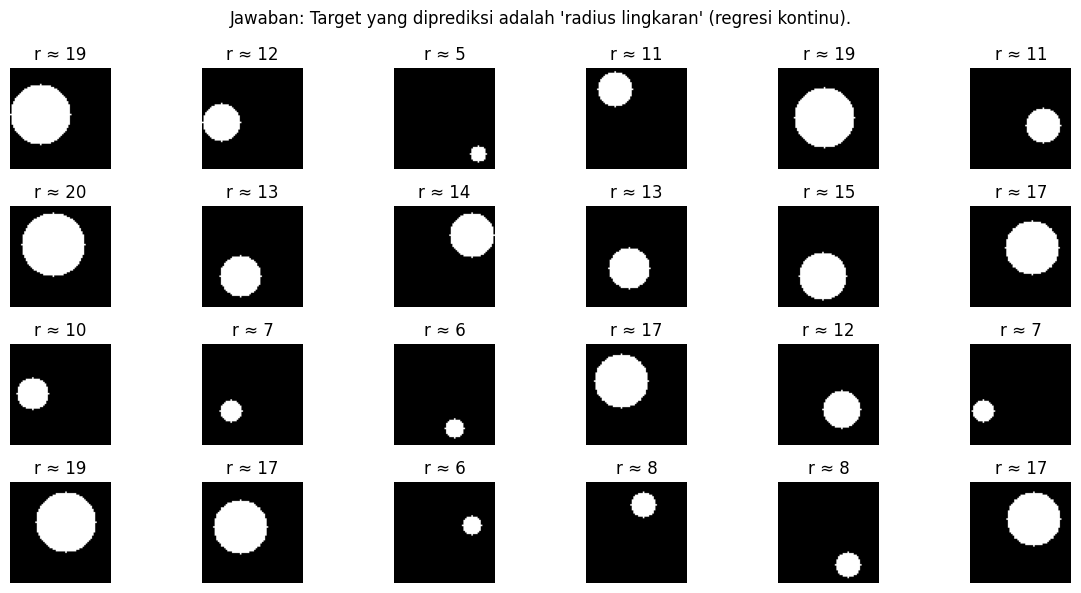

In [ ]:
# Tampilkan kembali, sekarang tampilkan radius (label) di judul tiap subplot
plt.figure(figsize=(12, 6))
for i in range(N_show):
  plt.subplot(rows, cols, i+1)
  plt.imshow(imgs[i].squeeze(), cmap='gray')
  plt.title(f"r ≈ {int(rads[i])}")
  plt.axis('off')
plt.suptitle("Jawaban: Target yang diprediksi adalah 'radius lingkaran' (regresi kontinu).")
plt.tight_layout()
plt.show()

19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step
MAE=0.948 | RMSE=1.158 | R²=0.938


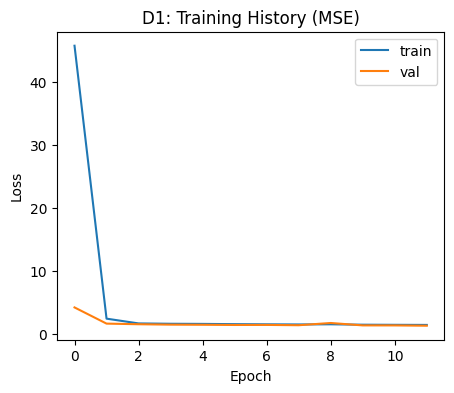

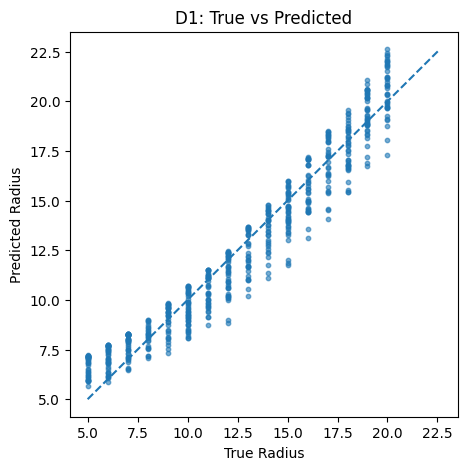

In [ ]:
from sklearn import metrics
# Siapkan dataset lebih besar untuk training
N = 3000
X, y, C = zip(*[make_sample() for _ in range(N)])
X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.float32)

Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42)

# Model CNN sederhana
model = models.Sequential([
    layers.Input((64,64,3)),
    layers.Conv2D(32, 3, activation='relu'), layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'), layers.MaxPooling2D(),
    layers.Conv2D(128, 3, activation='relu'), layers.GlobalAveragePooling2D(),
    layers.Dense(64, activation='relu'),
    layers.Dense(1) #Output regresi
])
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
history = model.fit(Xtr, ytr, validation_data=(Xte, yte), epochs=12, batch_size=64, verbose=0)

# Evaluasi
y_pred = model.predict(Xte).ravel()
mae = mean_absolute_error(yte, y_pred)
rmse = float(np.sqrt(np.mean((yte - y_pred)**2)))
r2 = r2_score(yte, y_pred)
print(f"MAE={mae:.3f} | RMSE={rmse:.3f} | R²={r2:.3f}")

# Plot loss
plt.figure(figsize=(5,4))
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title("D1: Training History (MSE)")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend(); plt.show()

# Scatter True vs Pred
plt.figure(figsize=(5,5))
plt.scatter(yte, y_pred, s=10, alpha=0.6)
lims = [min(yte.min(), y_pred.min()), max(yte.max(), y_pred.max())]
plt.plot(lims, lims, '--')
plt.xlabel("True Radius"); plt.ylabel("Predicted Radius")
plt.title("D1: True vs Predicted")
plt.show()

###Tantangan Mini: Ubah rentang radius, Tambah noise, multi-output

19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 89ms/step
--- HASIL EVALUASI TANTANGAN MINI D1 ---
Radius (r) -> MAE: 1.020 | RMSE: 1.259 | R²: 0.955
Center-X (cx) -> MAE: 4.040 | RMSE: 5.373 | R²: 0.616
Center-Y (cy) -> MAE: 3.638 | RMSE: 5.126 | R²: 0.643


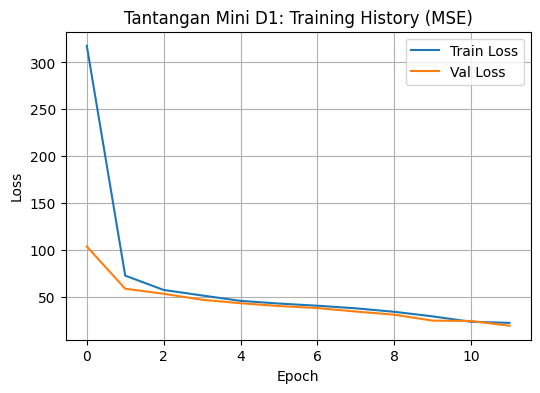

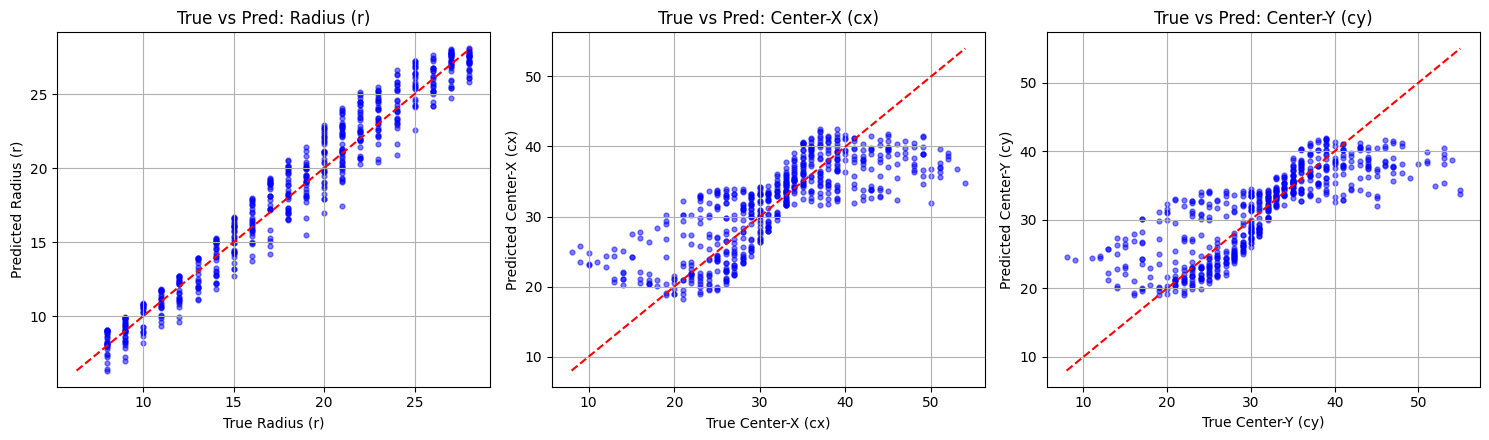

In [ ]:
# Menambahkan Noise
def make_sample_tantangan(img_size=64, min_r=8, max_r=28): #Rentang radius diubah ke 8-28
    r = np.random.randint(min_r, max_r + 1)
    img = np.zeros((img_size, img_size), dtype=np.uint8)
    cx = np.random.randint(r, img_size - r)
    cy = np.random.randint(r, img_size - r)
    cv2.circle(img, (cx, cy), r, (255,), -1)

    # Penambahan Gaussian Noise ke citra
    noise = np.random.normal(0, 20, (img_size, img_size)).astype(np.int16)
    img_noisy = np.clip(img.astype(np.int16) + noise, 0, 255).astype(np.uint8)

    img_noisy = (img_noisy / 255.0).astype(np.float32)
    img3 = np.stack([img_noisy, img_noisy, img_noisy], axis=-1)

    # Target Multi-Output: [radius, center_x, center_y]
    target_multi = np.array([float(r), float(cx), float(cy)], dtype=np.float32)

    return img3, target_multi

# Dataset yang lebih besar
N = 3000
samples_tm = [make_sample_tantangan() for _ in range(N)]
X_tm = np.array([s[0] for s in samples_tm], dtype=np.float32)
y_tm = np.array([s[1] for s in samples_tm], dtype=np.float32)

Xtr_tm, Xte_tm, ytr_tm, yte_tm = train_test_split(X_tm, y_tm, test_size=0.2, random_state=42)

# Model CNN Multi-Output
model_tm = models.Sequential([
    layers.Input((64, 64, 3)),
    layers.Conv2D(32, 3, activation='relu'), layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'), layers.MaxPooling2D(),
    layers.Conv2D(128, 3, activation='relu'), layers.GlobalAveragePooling2D(),
    layers.Dense(64, activation='relu'),
    layers.Dense(3) # Output 3 neuron untuk memprediksi [r, cx, cy] sekaligus
])

model_tm.compile(optimizer='adam', loss='mse', metrics=['mae'])
history_tm = model_tm.fit(Xtr_tm, ytr_tm, validation_data=(Xte_tm, yte_tm), epochs=12, batch_size=64, verbose=0)

# Evaluasi Performa Multi-Output
y_pred_tm = model_tm.predict(Xte_tm)

labels = ['Radius (r)', 'Center-X (cx)', 'Center-Y (cy)']
print("--- HASIL EVALUASI TANTANGAN MINI D1 ---")
for i in range(3):
    mae_i = mean_absolute_error(yte_tm[:, i], y_pred_tm[:, i])
    rmse_i = float(np.sqrt(np.mean((yte_tm[:, i] - y_pred_tm[:, i])**2)))
    r2_i = r2_score(yte_tm[:, i], y_pred_tm[:, i])
    print(f"{labels[i]} -> MAE: {mae_i:.3f} | RMSE: {rmse_i:.3f} | R²: {r2_i:.3f}")

# Plot Training History (Loss MSE)
plt.figure(figsize=(6, 4))
plt.plot(history_tm.history['loss'], label='Train Loss')
plt.plot(history_tm.history['val_loss'], label='Val Loss')
plt.title("Tantangan Mini D1: Training History (MSE)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

# Plot Scatter True vs Predicted untuk ketiga output (r, cx, cy)
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
targets_name = ['Radius (r)', 'Center-X (cx)', 'Center-Y (cy)']

for i in range(3):
    axes[i].scatter(yte_tm[:, i], y_pred_tm[:, i], s=12, alpha=0.5, color='blue')
    lims = [min(yte_tm[:, i].min(), y_pred_tm[:, i].min()), max(yte_tm[:, i].max(), y_pred_tm[:, i].max())]
    axes[i].plot(lims, lims, 'r--', label='Ideal')
    axes[i].set_xlabel(f"True {targets_name[i]}")
    axes[i].set_ylabel(f"Predicted {targets_name[i]}")
    axes[i].set_title(f"True vs Pred: {targets_name[i]}")
    axes[i].grid(True)

plt.tight_layout()
plt.show()

##Praktikum D2 - Menebak Umur Manusia dari Foto Wajah (UTKFace)

In [ ]:
# API token kaggle
!mkdir -p ~/.kaggle && echo KGAT_20a9ef15a1bc4e3bf025a52c6afff015 > ~/.kaggle/access_token && chmod 600 ~/.kaggle/access_token

In [ ]:
# Unduh dataset UTKFace
!kaggle datasets download -d jangedoo/utkface-new -p /content -q
!unzip -q /content/utkface-new.zip -d /content/utk
print("✅ Dataset UTKFace berhasil diekstrak.")

Dataset URL: https://www.kaggle.com/datasets/jangedoo/utkface-new
License(s): copyright-authors
✅ Dataset UTKFace berhasil diekstrak.


Total gambar ditemukan: 23708


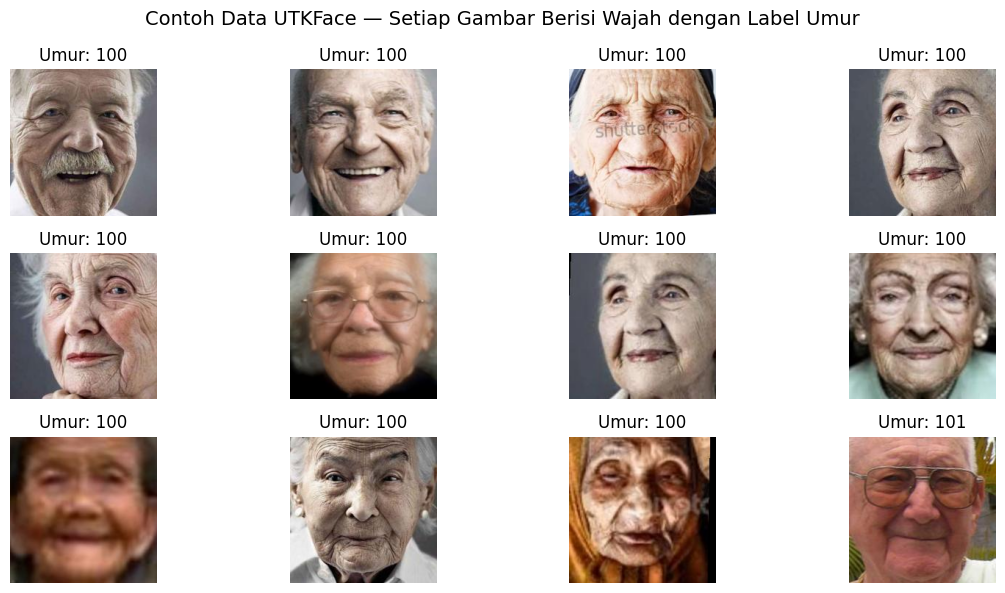

In [ ]:
import matplotlib.pyplot as plt
import os, glob
from PIL import Image

# Ambil 12 gambar acak dari dataset
files = glob.glob("/content/utk/UTKFace/*.jpg")
files = sorted(files)
print(f"Total gambar ditemukan: {len(files)}")

plt.figure(figsize=(12, 6))
for i, f in enumerate(files[:12]):
  # Ambil umur dari nama file
  age = int(os.path.basename(f).split("_")[0])
  img = Image.open(f)
  plt.subplot(3, 4, i + 1)
  plt.imshow(img)
  plt.title(f"Umur: {age}")
  plt.axis("off")
plt.suptitle("Contoh Data UTKFace — Setiap Gambar Berisi Wajah dengan Label Umur", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
import tensorflow as tf
import numpy as np
from sklearn.model_selection import train_test_split

def parse_age_from_name(fp):
  return int(os.path.basename(fp).split('_')[0])

ages = np.array([parse_age_from_name(f) for f in files], dtype=np.float32)
train_files, test_files, y_train, y_test = train_test_split(
    files, ages, test_size=0.2, random_state=42
)

IMG_SIZE = 160
def load_img(fp, label):
  img = tf.io.read_file(fp)
  img = tf.image.decode_jpeg(img, channels=3)
  img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
  return img / 255.0, label

train_ds = tf.data.Dataset.from_tensor_slices((train_files, y_train)).map(load_img).batch(64)
test_ds = tf.data.Dataset.from_tensor_slices((test_files, y_test)).map(load_img).batch(64)

print("✅ Dataset siap dilatih.")

✅ Dataset siap dilatih.


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

# Gunakan GPU jika tersedia
print("Hardware:", "GPU" if tf.config.list_physical_devices('GPU') else "CPU")

# Buat arsitektur model
base_model = tf.keras.applications.MobileNetV2(
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    weights='imagenet'
)
base_model.trainable = False # tahap awal: freeze backbone

# Tambahkan head regresi
inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = tf.keras.applications.mobilenet_v2.preprocess_input(inputs * 255.0)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
x = layers.Dense(128, activation='relu')(x)
outputs = layers.Dense(1)(x) #output tunggal: umur
model = tf.keras.Model(inputs, outputs)

# Kompilasi model
model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss='mse', metrics=['mae'])
model.summary()

Hardware: CPU


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ multiply (Multiply)             │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 316s 1s/step - loss: 215.4147 - mae: 10.9489 - val_loss: 156.9883 - val_mae: 9.5332 - learning_rate: 0.0010
Epoch 2/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 310s 1s/step - loss: 150.1867 - mae: 9.1321 - val_loss: 146.0646 - val_mae: 9.0773 - learning_rate: 0.0010
Epoch 3/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 318s 1s/step - loss: 142.2068 - mae: 8.8578 - val_loss: 141.3982 - val_mae: 8.9064 - learning_rate: 0.0010
Epoch 4/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 332s 1s/step - loss: 139.3053 - mae: 8.6965 - val_loss: 138.1714 - val_mae: 8.7136 - learning_rate: 0.0010
Epoch 5/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 320s 1s/step - loss: 135.2614 - mae: 8.5651 - val_loss: 138.5506 - val_mae: 8.7594 - learning_rate: 0.0010
Epoch 6/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 310s 1s/step - loss: 134.3989 - mae: 8.5367 - val_loss: 134.7023 - val_mae: 8.5879 - learning_rate: 0.0010
Epoch 7/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 317s 1s/step - loss: 130.4145 - mae: 8.3961 - val_loss: 134.0779 - val_mae: 8

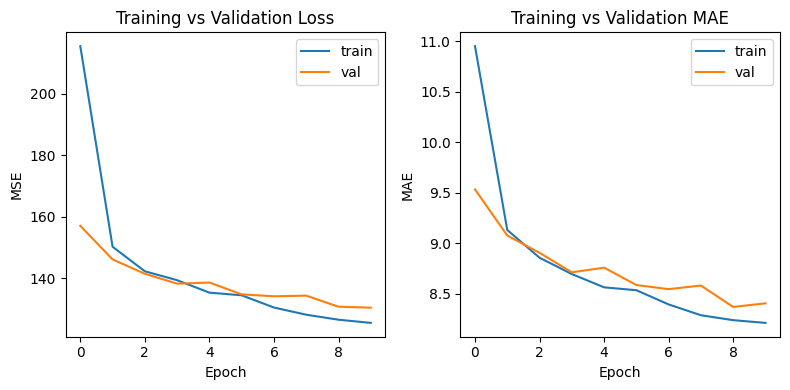

In [ ]:
# Callback untuk pelatiha yang lebih stabil
cb = [
    tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True, monitor='val_loss'),
    tf.keras.callbacks.ReduceLROnPlateau(patience=2, factor=0.5, min_lr=1e-5, monitor='val_loss')
]

history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=10,
    callbacks=cb,
    verbose=1
)

# Visualisasi perubahan loss dan MAE selama pelatihan:
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.xlabel('Epoch'); plt.ylabel('MSE'); plt.title('Training vs Validation Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['mae'], label='train')
plt.plot(history.history['val_mae'], label='val')
plt.xlabel('Epoch'); plt.ylabel('MAE')
plt.title('Training vs Validation MAE')
plt.legend()
plt.tight_layout()
plt.show()

Epoch 1/5
297/297 ━━━━━━━━━━━━━━━━━━━━ 380s 1s/step - loss: 146.1973 - mae: 8.9080 - val_loss: 135.0591 - val_mae: 8.9443 - learning_rate: 1.0000e-04
Epoch 2/5
297/297 ━━━━━━━━━━━━━━━━━━━━ 398s 1s/step - loss: 71.1553 - mae: 6.3349 - val_loss: 124.4077 - val_mae: 8.6457 - learning_rate: 1.0000e-04
Epoch 3/5
297/297 ━━━━━━━━━━━━━━━━━━━━ 372s 1s/step - loss: 48.3982 - mae: 5.2836 - val_loss: 121.8847 - val_mae: 8.4600 - learning_rate: 1.0000e-04
Epoch 4/5
297/297 ━━━━━━━━━━━━━━━━━━━━ 375s 1s/step - loss: 35.7950 - mae: 4.5609 - val_loss: 119.6197 - val_mae: 8.4082 - learning_rate: 1.0000e-04
Epoch 5/5
297/297 ━━━━━━━━━━━━━━━━━━━━ 393s 1s/step - loss: 29.0153 - mae: 4.0978 - val_loss: 112.4538 - val_mae: 7.9338 - learning_rate: 1.0000e-04


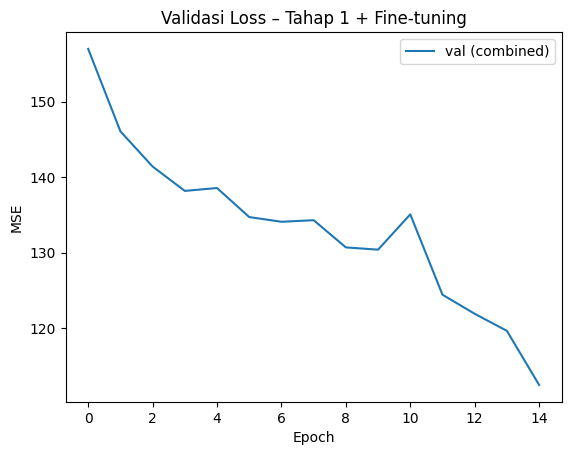

In [ ]:
# Aktifkan kembali sebagian layer terakhir untuk fine-tuning
base_model.trainable = True
for layer in base_model.layers[:-30]:
  layer.trainable = False #beku sebagian besar layer

# Recompile dengan learning rate lebih kecil
model.compile(optimizer=tf.keras.optimizers.Adam(1e-4), loss='mse', metrics=['mae'])

history_ft = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=5,
    callbacks=cb,
    verbose=1
)

# Visualisasi gabungan training dan fine-tuning:
plt.plot(history.history['val_loss'] + history_ft.history['val_loss'], label='val (combined)')
plt.title("Validasi Loss – Tahap 1 + Fine-tuning")
plt.xlabel("Epoch"); plt.ylabel("MSE")
plt.legend(); plt.show()

MAE = 7.93 tahun
RMSE = 10.60 tahun
R²	= 0.717


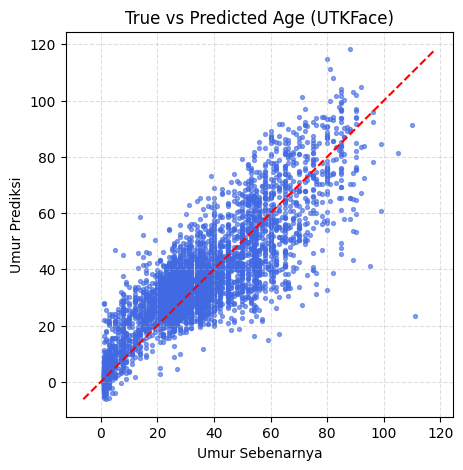

In [ ]:
from math import sqrt

y_pred = np.concatenate([model.predict(batch[0], verbose=0).ravel() for batch in test_ds])
mae = mean_absolute_error(y_test, y_pred)
rmse = sqrt(np.mean((y_test - y_pred)**2))
r2 = r2_score(y_test, y_pred)

print(f"MAE = {mae:.2f} tahun")
print(f"RMSE = {rmse:.2f} tahun")
print(f"R²	= {r2:.3f}")

# Plot "umur sebenarnya vs umur prediksi":
plt.figure(figsize=(5,5))
plt.scatter(y_test, y_pred, s=8, alpha=0.6, color='royalblue')
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, '--', color='red')
plt.xlabel("Umur Sebenarnya")
plt.ylabel("Umur Prediksi")
plt.title("True vs Predicted Age (UTKFace)")
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

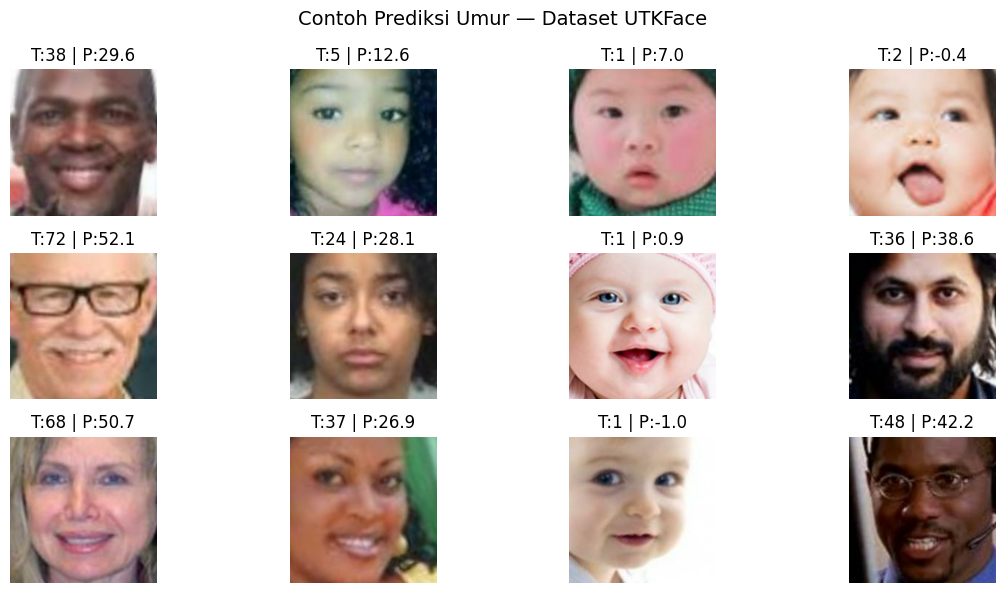

In [ ]:
import random
sample_paths = random.sample(test_files, 12)

plt.figure(figsize=(12,6))
for i, path in enumerate(sample_paths):
  img = tf.io.read_file(path)
  img = tf.image.decode_jpeg(img, channels=3)
  img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))/255.0
  true_age = int(os.path.basename(path).split('_')[0])
  pred_age = model.predict(tf.expand_dims(img, 0), verbose=0).ravel()[0]
  plt.subplot(3,4,i+1)
  plt.imshow(img.numpy())
  plt.title(f"T:{true_age} | P:{pred_age:.1f}")
  plt.axis('off')
plt.suptitle("Contoh Prediksi Umur — Dataset UTKFace", fontsize=14)
plt.tight_layout()
plt.show()

##Praktikum D3 - Menilai "Kepopuleran Hewan Peliharaan" dari Foto

In [ ]:
!pip -q install -U kaggle
import os
from getpass import getpass

os.environ["KAGGLE_API_TOKEN"] = getpass("Masukkan Kaggle API Token: ")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.2/126.2 kB 1.2 MB/s eta 0:00:00
Masukkan Kaggle API Token: ··········


In [ ]:
!kaggle --version

Kaggle CLI 2.2.4


In [ ]:
!kaggle competitions files -c petfinder-pawpularity-score

Next Page Token = CfDJ8LXGgraiXMNClPzcySXY5U6SjV7mYPTx8WATYfXWKlATVuFIW8Pxrm3IQUO-RlI_oJPNgVgKdawQle020rPFDizfBz6h6ECHV8gGDA6OJsZbht1PJ3vJYeOjCfTBS08AUFE-EP2ZW3ibngnH61_4JQN4BcYi6TCl1bPZoC23cXvcEO0s
name                                              size  creationDate                
------------------------------------------  ----------  --------------------------  
sample_submission.csv                              326  2021-09-22 20:29:22.950000  
test.csv                                           545  2021-09-22 20:29:22.981000  
test/4128bae22183829d2b5fea10effdb0c3.jpg        10464  2021-09-22 20:29:41.131000  
test/43a2262d7738e3d420d453815151079e.jpg        10424  2021-09-22 20:29:41.108000  
test/4e429cead1848a298432a0acad014c9d.jpg        10506  2021-09-22 20:29:41.118000  
test/80bc3ccafcc51b66303c2c263aa38486.jpg        10498  2021-09-22 20:29:41.131000  
test/8f49844c382931444e68dffbe20228f4.jpg        10458  2021-09-22 20:29:41.096000  
test/b03f7041962238a7c9d6537e22f9b01

In [ ]:
!kaggle competitions download -c petfinder-pawpularity-score -p /content -q
!unzip -q /content/petfinder-pawpularity-score.zip -d /content/paw
print("✅ Dataset Pawpularity berhasil diekstrak.")

403 Client Error: Forbidden for url: https://api.kaggle.com/v1/competitions.CompetitionApiService/DownloadDataFiles
unzip:  cannot find or open /content/petfinder-pawpularity-score.zip, /content/petfinder-pawpularity-score.zip.zip or /content/petfinder-pawpularity-score.zip.ZIP.
✅ Dataset Pawpularity berhasil diekstrak.


In [ ]:
!kaggle datasets download -d schulta/petfinder-pawpularity-score-clean -p /content

Dataset URL: https://www.kaggle.com/datasets/schulta/petfinder-pawpularity-score-clean
License(s): CC0-1.0
100% 980M/980M [00:13<00:00, 75.6MB/s]



In [ ]:
import os

for f in os.listdir("/content"):
    if "pawpularity" in f.lower():
        path = os.path.join("/content", f)
        print(f, "->", round(os.path.getsize(path) / (1024**2), 2), "MB")

petfinder-pawpularity-score-clean.zip -> 980.18 MB


In [ ]:
import zipfile
import os

zip_path = "/content/petfinder-pawpularity-score-clean.zip"

print("Ukuran ZIP:",
      round(os.path.getsize(zip_path) / (1024**2), 2),
      "MB")

print("ZIP valid:",
      zipfile.is_zipfile(zip_path))

Ukuran ZIP: 980.18 MB
ZIP valid: True


In [ ]:
with zipfile.ZipFile(zip_path, "r") as z:
    files = z.namelist()

print("Jumlah file:", len(files))

print("\n20 file pertama:")
for f in files[:20]:
    print(f)

Jumlah file: 9896

20 file pertama:
sample_submission.csv
test.csv
test/4128bae22183829d2b5fea10effdb0c3.jpg
test/43a2262d7738e3d420d453815151079e.jpg
test/4e429cead1848a298432a0acad014c9d.jpg
test/80bc3ccafcc51b66303c2c263aa38486.jpg
test/8f49844c382931444e68dffbe20228f4.jpg
test/b03f7041962238a7c9d6537e22f9b017.jpg
test/c978013571258ed6d4637f6e8cc9d6a3.jpg
test/e0de453c1bffc20c22b072b34b54e50f.jpg
train.csv
train/0007de18844b0dbbb5e1f607da0606e0.jpg
train/0009c66b9439883ba2750fb825e1d7db.jpg
train/0013fd999caf9a3efe1352ca1b0d937e.jpg
train/0018df346ac9c1d8413cfcc888ca8246.jpg
train/001dc955e10590d3ca4673f034feeef2.jpg
train/001dd4f6fafb890610b1635f967ea081.jpg
train/0023b8a3abc93c712edd6120867deb53.jpg
train/0031d6a9ef7340f898c3e05f92c7bb04.jpg
train/0042bc5bada6d1cf8951f8f9f0d399fa.jpg


In [ ]:
csv_files = [
    f for f in files
    if f.lower().endswith(".csv")
]

image_files = [
    f for f in files
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

print("File CSV:")
for f in csv_files:
    print(" -", f)

print("\nJumlah gambar:", len(image_files))

File CSV:
 - sample_submission.csv
 - test.csv
 - train.csv

Jumlah gambar: 9893


In [ ]:
import zipfile
import os

zip_path = "/content/petfinder-pawpularity-score-clean.zip"
extract_path = "/content/paw"

with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(extract_path)

print("✅ Dataset berhasil diekstrak.")

✅ Dataset berhasil diekstrak.


In [ ]:
print(os.listdir("/content/paw"))

['train.csv', 'train', 'test', 'sample_submission.csv', 'test.csv']


In [ ]:
import pandas as pd

df = pd.read_csv("/content/paw/train.csv")

print("Ukuran dataset:", df.shape)

print("\nKolom dataset:")
print(df.columns.tolist())

print("\n5 data pertama:")
display(df.head())

Ukuran dataset: (9885, 14)

Kolom dataset:
['Id', 'Subject Focus', 'Eyes', 'Face', 'Near', 'Action', 'Accessory', 'Group', 'Collage', 'Human', 'Occlusion', 'Info', 'Blur', 'Pawpularity']

5 data pertama:


,Id,Subject Focus,Eyes,Face,Near,Action,Accessory,Group,Collage,Human,Occlusion,Info,Blur,Pawpularity
0,0007de18844b0dbbb5e1f607da0606e0,0,1,1,1,0,0,1,0,0,0,0,0,63
1,0009c66b9439883ba2750fb825e1d7db,0,1,1,0,0,0,0,0,0,0,0,0,42
2,0013fd999caf9a3efe1352ca1b0d937e,0,1,1,1,0,0,0,0,1,1,0,0,28
3,0018df346ac9c1d8413cfcc888ca8246,0,1,1,1,0,0,0,0,0,0,0,0,15
4,001dc955e10590d3ca4673f034feeef2,0,0,0,1,0,0,1,0,0,0,0,0,72


In [ ]:
df["path"] = df["Id"].apply(
    lambda x: f"/content/paw/train/{x}.jpg"
)

print(df[["Id", "Pawpularity", "path"]].head())

                                 Id  Pawpularity  \
0  0007de18844b0dbbb5e1f607da0606e0           63   
1  0009c66b9439883ba2750fb825e1d7db           42   
2  0013fd999caf9a3efe1352ca1b0d937e           28   
3  0018df346ac9c1d8413cfcc888ca8246           15   
4  001dc955e10590d3ca4673f034feeef2           72   

                                                path  
0  /content/paw/train/0007de18844b0dbbb5e1f607da0...  
1  /content/paw/train/0009c66b9439883ba2750fb825e...  
2  /content/paw/train/0013fd999caf9a3efe1352ca1b0...  
3  /content/paw/train/0018df346ac9c1d8413cfcc888c...  
4  /content/paw/train/001dc955e10590d3ca4673f034f...  


In [ ]:
df["exists"] = df["path"].apply(os.path.exists)

print("Foto ditemukan :", df["exists"].sum())
print("Foto tidak ditemukan :", (~df["exists"]).sum())

Foto ditemukan : 9885
Foto tidak ditemukan : 0


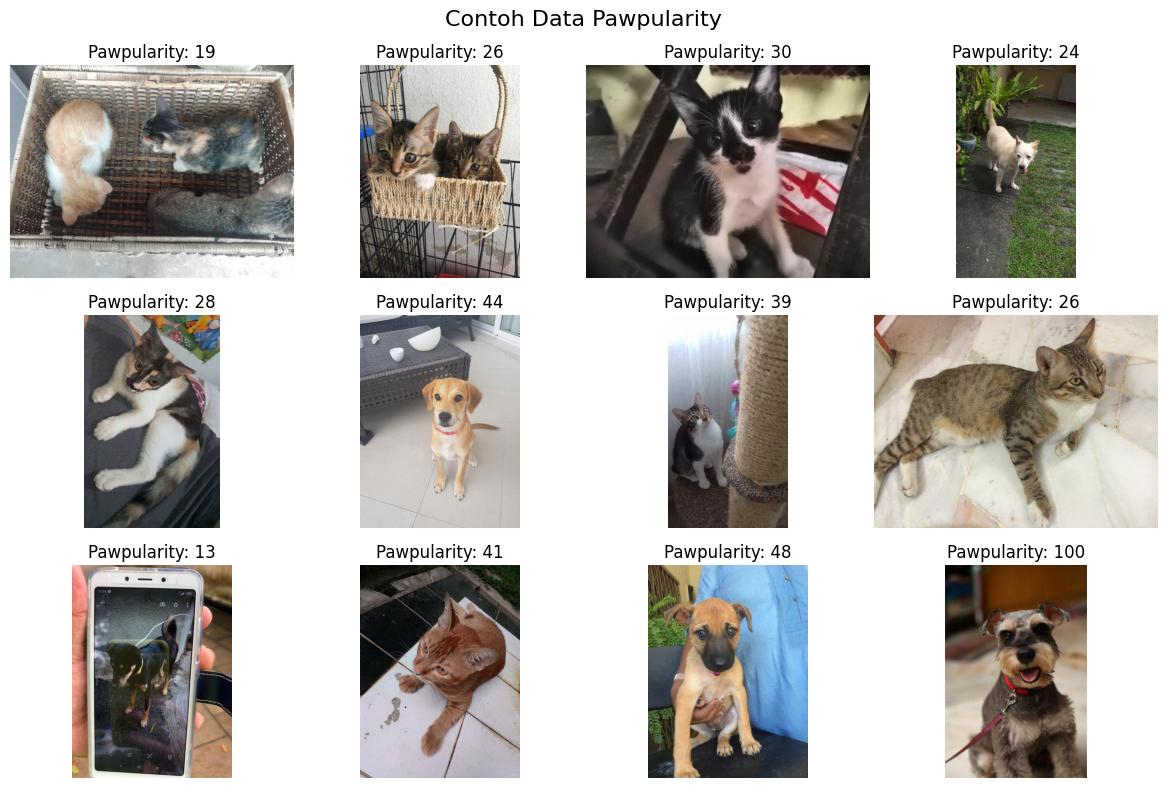

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

sample_df = df.sample(
    12,
    random_state=42
)

plt.figure(figsize=(12, 8))

for i, row in enumerate(sample_df.itertuples()):
    img = Image.open(row.path)

    plt.subplot(3, 4, i + 1)
    plt.imshow(img)
    plt.title(f"Pawpularity: {row.Pawpularity}")
    plt.axis("off")

plt.suptitle(
    "Contoh Data Pawpularity",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

# Ambil hanya data yang diperlukan
data = df[["path", "Pawpularity"]].copy()

# Split 80% training, 20% validation
train_df, val_df = train_test_split(
    data,
    test_size=0.20,
    random_state=42
)

print("Jumlah data keseluruhan :", len(data))
print("Jumlah data training    :", len(train_df))
print("Jumlah data validation  :", len(val_df))

Jumlah data keseluruhan : 9885
Jumlah data training    : 7908
Jumlah data validation  : 1977


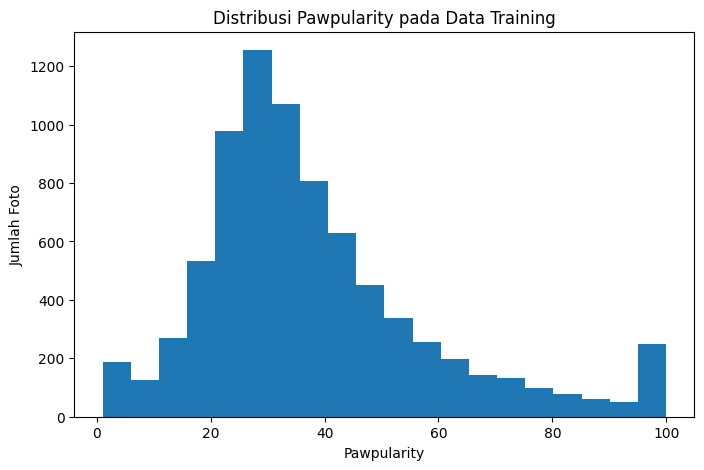

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(
    train_df["Pawpularity"],
    bins=20
)

plt.xlabel("Pawpularity")
plt.ylabel("Jumlah Foto")
plt.title("Distribusi Pawpularity pada Data Training")

plt.show()

In [ ]:
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [ ]:
def load_image(path, label):
    # Baca file gambar
    image = tf.io.read_file(path)

    # Decode JPG menjadi tensor
    image = tf.image.decode_jpeg(
        image,
        channels=3
    )

    # Resize menjadi 224x224
    image = tf.image.resize(
        image,
        IMG_SIZE
    )

    # Pastikan tipe float32
    image = tf.cast(
        image,
        tf.float32
    )

    return image, label

In [ ]:
train_paths = train_df["path"].values
train_labels = train_df["Pawpularity"].values.astype("float32")

val_paths = val_df["path"].values
val_labels = val_df["Pawpularity"].values.astype("float32")

train_ds = tf.data.Dataset.from_tensor_slices(
    (train_paths, train_labels)
)

val_ds = tf.data.Dataset.from_tensor_slices(
    (val_paths, val_labels)
)

train_ds = train_ds.map(
    load_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

val_ds = val_ds.map(
    load_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

train_ds = train_ds.shuffle(
    buffer_size=1000,
    seed=42
).batch(
    BATCH_SIZE
).prefetch(
    tf.data.AUTOTUNE
)

val_ds = val_ds.batch(
    BATCH_SIZE
).prefetch(
    tf.data.AUTOTUNE
)

In [ ]:
for images, labels in train_ds.take(1):
    print("Shape gambar :", images.shape)
    print("Shape label  :", labels.shape)
    print("Contoh label :", labels[:5].numpy())

Shape gambar : (32, 224, 224, 3)
Shape label  : (32,)
Contoh label : [ 7.  2. 42. 36. 19.]


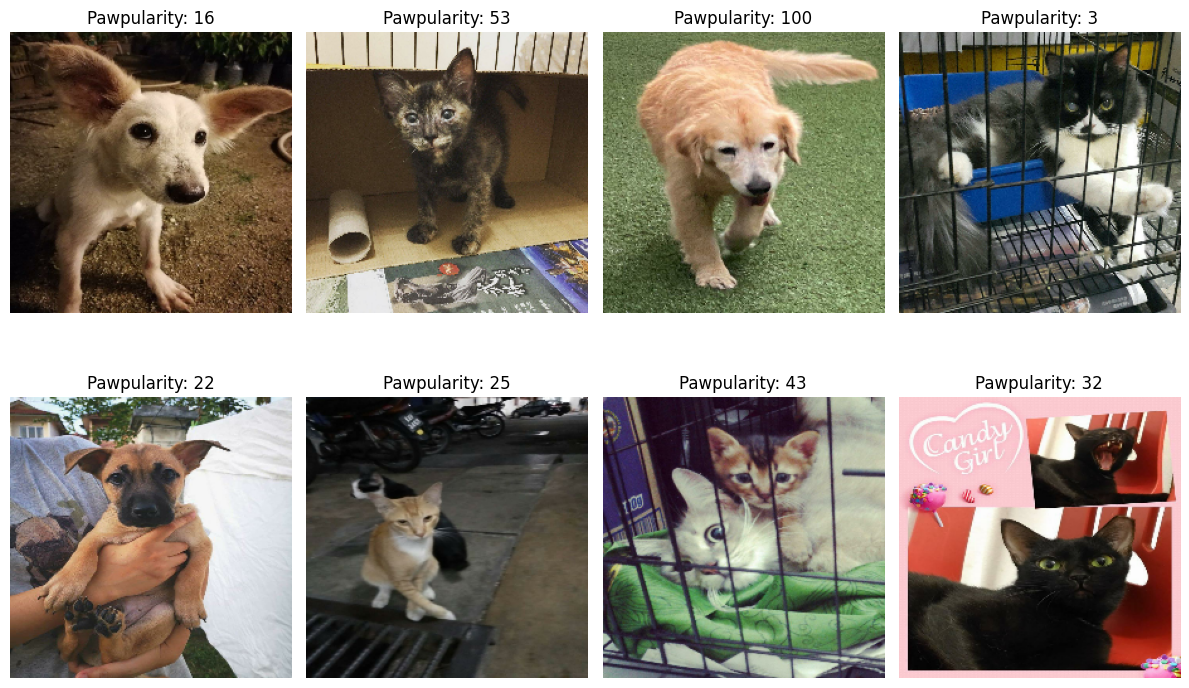

In [ ]:
plt.figure(figsize=(12, 8))

for images, labels in train_ds.take(1):
    for i in range(8):
        plt.subplot(2, 4, i + 1)
        plt.imshow(
            images[i].numpy().astype("uint8")
        )
        plt.title(
            f"Pawpularity: {labels[i].numpy():.0f}"
        )
        plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
def load_image(path, label):
    # Baca gambar
    img = tf.io.read_file(path)

    # Decode JPG menjadi RGB
    img = tf.image.decode_jpeg(img, channels=3)

    # Resize menjadi 224x224
    img = tf.image.resize(img, IMG_SIZE)

    # Ubah ke float32, tetap dalam rentang 0-255
    img = tf.cast(img, tf.float32)

    return img, tf.cast(label, tf.float32)

In [ ]:
train_ds = tf.data.Dataset.from_tensor_slices(
    (
        train_df["path"].values,
        train_df["Pawpularity"].values
    )
)

train_ds = (
    train_ds
    .map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    .shuffle(4096, seed=42)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

val_ds = tf.data.Dataset.from_tensor_slices(
    (
        val_df["path"].values,
        val_df["Pawpularity"].values
    )
)

val_ds = (
    val_ds
    .map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

print("✅ Dataset berhasil dibuat ulang.")

✅ Dataset berhasil dibuat ulang.


In [ ]:
for images, labels in train_ds.take(1):
    print("Shape gambar :", images.shape)
    print("Range pixel  :", images.numpy().min(), "-", images.numpy().max())
    print("Shape label  :", labels.shape)

Shape gambar : (32, 224, 224, 3)
Range pixel  : 0.0 - 255.0
Shape label  : (32,)


In [ ]:
from tensorflow.keras import layers

# Backbone EfficientNetB0
base = tf.keras.applications.EfficientNetB0(
    include_top=False,
    input_shape=(224, 224, 3),
    weights="imagenet"
)

# Bekukan backbone
base.trainable = False

# Input
inputs = tf.keras.Input(
    shape=(224, 224, 3)
)

# Feature extraction
x = base(
    inputs,
    training=False
)

# Global pooling
x = layers.GlobalAveragePooling2D()(x)

# Dropout
x = layers.Dropout(0.3)(x)

# Fully connected layer
x = layers.Dense(
    256,
    activation="relu"
)(x)

# Output regresi
outputs = layers.Dense(1)(x)

# Model
model = tf.keras.Model(
    inputs,
    outputs
)

# Compile
model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

print("✅ EfficientNetB0 berhasil dibuat.")

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✅ EfficientNetB0 berhasil dibuat.


In [ ]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,377,764 (16.70 MB)

 Trainable params: 328,193 (1.25 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        patience=2,
        factor=0.5,
        verbose=1
    )
]

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 451s 2s/step - loss: 526.2676 - mae: 16.7559 - val_loss: 440.3175 - val_mae: 15.5845 - learning_rate: 0.0010
Epoch 2/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 469s 2s/step - loss: 398.0392 - mae: 14.7573 - val_loss: 403.3709 - val_mae: 15.1313 - learning_rate: 0.0010
Epoch 3/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 485s 2s/step - loss: 376.5358 - mae: 14.3124 - val_loss: 395.2023 - val_mae: 15.1086 - learning_rate: 0.0010
Epoch 4/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 404s 2s/step - loss: 360.6740 - mae: 14.1109 - val_loss: 380.6958 - val_mae: 14.3298 - learning_rate: 0.0010
Epoch 5/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 491s 2s/step - loss: 344.9952 - mae: 13.7857 - val_loss: 372.9025 - val_mae: 14.3817 - learning_rate: 0.0010
Epoch 6/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 461s 2s/step - loss: 334.6554 - mae: 13.5887 - val_loss: 370.6552 - val_mae: 14.4049 - learning_rate: 0.0010
Epoch 7/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 446s 2s/step - loss: 330.4506 - mae: 13.4768 - val_loss: 361.6945 

In [ ]:
# Simpan model yang baru saja selesai dilatih ke dalam file .keras
model.save("/content/best_pawpularity_model.keras")
print("✅ Model berhasil disimpan ke /content/best_pawpularity_model.keras")

# Sekarang kita bisa memuatnya kembali tanpa error
model_terbaik = tf.keras.models.load_model(
    "/content/best_pawpularity_model.keras"
)
print("✅ Model terbaik berhasil dimuat kembali dari file.")

✅ Model berhasil disimpan ke /content/best_pawpularity_model.keras
✅ Model terbaik berhasil dimuat kembali dari file.


In [ ]:
print("history ada :", "history" in globals())
print("model ada   :", "model" in globals())

history ada : True
model ada   : True


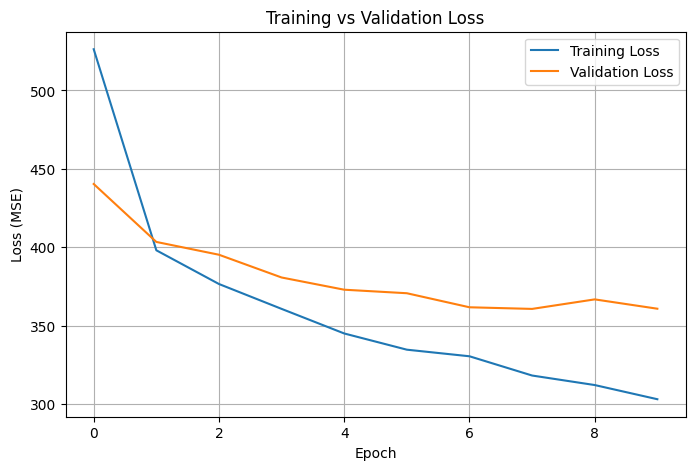

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

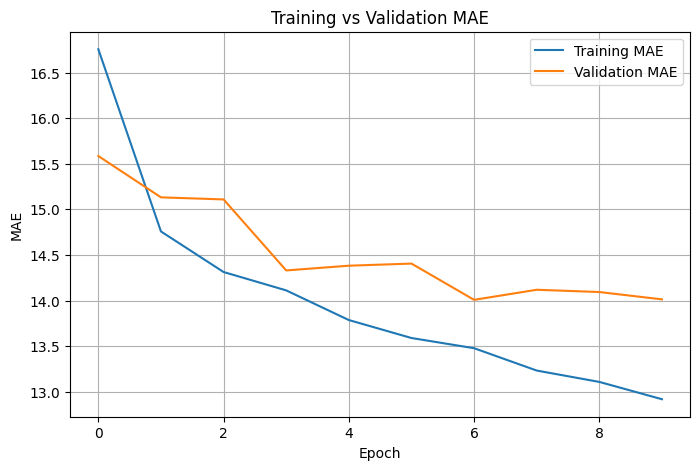

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["mae"],
    label="Training MAE"
)

plt.plot(
    history.history["val_mae"],
    label="Validation MAE"
)

plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.title("Training vs Validation MAE")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import numpy as np
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

y_true = []
y_pred = []

for images, labels in val_ds:
    predictions = model.predict(
        images,
        verbose=0
    )

    y_true.extend(labels.numpy())
    y_pred.extend(predictions.flatten())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Jumlah data aktual   :", len(y_true))
print("Jumlah data prediksi :", len(y_pred))

Jumlah data aktual   : 1977
Jumlah data prediksi : 1977


In [ ]:
mae = mean_absolute_error(
    y_true,
    y_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_true,
        y_pred
    )
)

r2 = r2_score(
    y_true,
    y_pred
)

print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

MAE  : 14.1179
RMSE : 18.9910
R²   : 0.1979


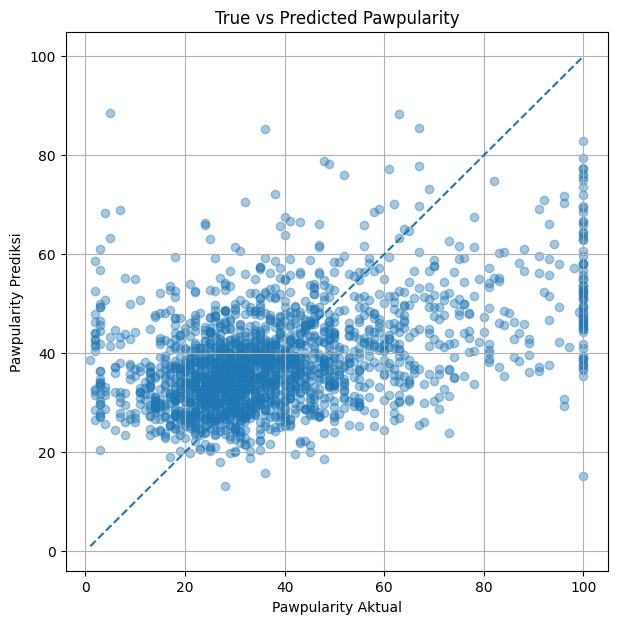

In [ ]:
plt.figure(figsize=(7, 7))

plt.scatter(
    y_true,
    y_pred,
    alpha=0.4
)

min_val = min(
    y_true.min(),
    y_pred.min()
)

max_val = max(
    y_true.max(),
    y_pred.max()
)

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--"
)

plt.xlabel("Pawpularity Aktual")
plt.ylabel("Pawpularity Prediksi")
plt.title("True vs Predicted Pawpularity")
plt.grid(True)

plt.show()

###12 Foto Actual vs Predicted

In [ ]:
sample_indices = np.random.RandomState(42).choice(
    len(val_df),
    size=12,
    replace=False
)

sample_val = val_df.iloc[sample_indices].copy()

In [ ]:
sample_images = []
sample_labels = []

for path, label in zip(
    sample_val["path"],
    sample_val["Pawpularity"]
):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(
        img,
        channels=3
    )
    img = tf.image.resize(
        img,
        (224, 224)
    )
    img = tf.cast(
        img,
        tf.float32
    )

    sample_images.append(img)
    sample_labels.append(label)

sample_images = tf.stack(sample_images)

sample_predictions = model.predict(
    sample_images,
    verbose=0
).flatten()

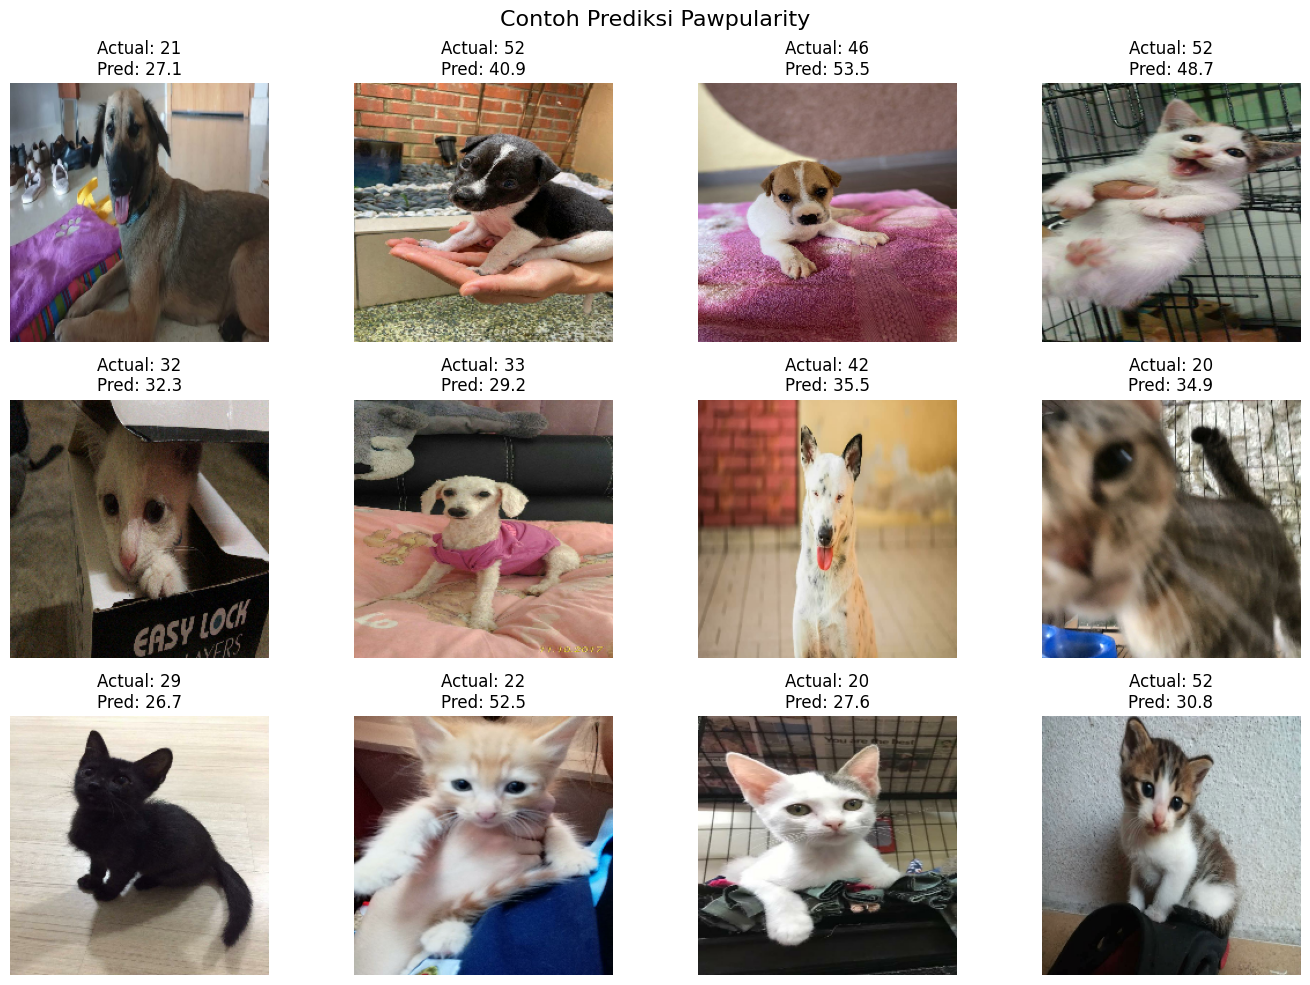

In [ ]:
plt.figure(figsize=(14, 10))

for i in range(12):
    plt.subplot(3, 4, i + 1)

    img = sample_images[i].numpy().astype("uint8")

    plt.imshow(img)

    plt.title(
        f"Actual: {sample_labels[i]:.0f}\n"
        f"Pred: {sample_predictions[i]:.1f}"
    )

    plt.axis("off")

plt.suptitle(
    "Contoh Prediksi Pawpularity",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [ ]:
import os

# Buat dataframe baru dari sample_val
hasil_12 = sample_val.copy()

# Ekstrak ID dari 'path' (misal dari /content/paw/train/xyz.jpg menjadi xyz)
hasil_12["Id"] = hasil_12["path"].apply(lambda x: os.path.splitext(os.path.basename(x))[0])

# Atur urutan kolom
hasil_12 = hasil_12[["Id", "Pawpularity"]]

# Tambahkan prediksi dan hitung selisih errornya
hasil_12["Prediksi"] = sample_predictions
hasil_12["Error"] = (
    hasil_12["Pawpularity"] -
    hasil_12["Prediksi"]
).abs()

hasil_12

,Id,Pawpularity,Prediksi,Error
5506,8e5d166f285237fbd3561c5393746aae,21,27.063799,6.063799
6225,a14baa85d40c2d6d6363360415c8e567,52,40.928383,11.071617
8747,e30400e6dca8eee851c3e3706bbfd253,46,53.453396,7.453396
713,1244abf9b327b1dc7028ac889ae62e86,52,48.671463,3.328537
5502,8e2e8b360d4fa493f09fcd23037fe3a3,32,32.297646,0.297646
9092,eb9431149b4193b209d06ec3ad60feb9,33,29.209818,3.790182
1558,27c6401ab71aafc879804b6c4f039162,42,35.506153,6.493847
8490,dca133f2fde3decd65d4e8574065e7bf,20,34.920147,14.920147
1402,2410f4640d5c032ab0934e753316ce34,29,26.695345,2.304655
5601,907d073f12b6411781fc452988cfa23b,22,52.543514,30.543514


##Penugasan

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Hurry.jpeg to Hurry.jpeg


In [ ]:
from PIL import Image
import tensorflow as tf
import matplotlib.pyplot as plt
import os

# Ambil nama file yang diupload
filename = list(uploaded.keys())[0]

# Load gambar
img = Image.open(filename).convert("RGB")

# Preprocessing sesuai model
img_resized = img.resize((224, 224))

img_array = tf.keras.utils.img_to_array(img_resized)
img_array = img_array / 255.0
img_array = tf.expand_dims(img_array, axis=0)

# Prediksi
prediction = model.predict(img_array, verbose=0)[0][0]

print("Nama file :", filename)
print(f"Prediksi Pawpularity : {prediction:.2f}")

Nama file : Hurry.jpeg
Prediksi Pawpularity : 7.75


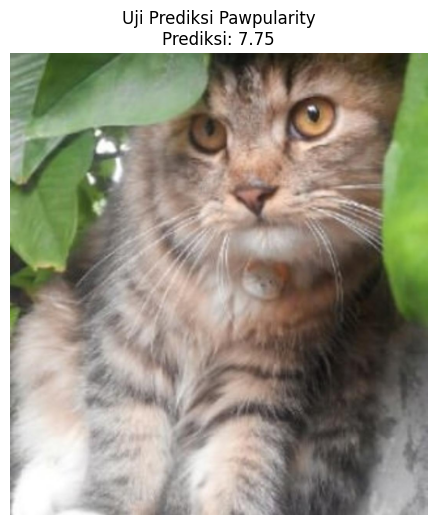

In [ ]:
plt.figure(figsize=(6, 6))

plt.imshow(img)
plt.title(
    f"Uji Prediksi Pawpularity\n"
    f"Prediksi: {prediction:.2f}"
)

plt.axis("off")
plt.show()